# Gaussian Mixture Model Simulation

Simulate samples from a three-component Gaussian mixture model with means `200`, `300`, and `500`, and standard deviations `20`, `60`, and `150`.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

means = np.array([200, 300, 500])
stds = np.array([20, 60, 150])
weights = np.array([1/3, 1/3, 1/3])

n_samples = 10_000

In [20]:
components = rng.choice(len(means), size=n_samples, p=weights)
samples = rng.normal(loc=means[components], scale=stds[components])

samples[:10]

array([217.50073982, 367.82867057, 677.40872911, 428.84497784,
       210.42551861, 467.43519139, 536.28625925, 327.91108651,
       212.44985246, 201.52888619])

In [21]:
print(f"Sample mean: {samples.mean():.2f}")
print(f"Sample std:  {samples.std(ddof=1):.2f}")
print("Component counts:")
for i, count in enumerate(np.bincount(components, minlength=len(means))):
    print(f"  component {i}: {count}")

Sample mean: 332.49
Sample std:  156.60
Component counts:
  component 0: 3375
  component 1: 3358
  component 2: 3267


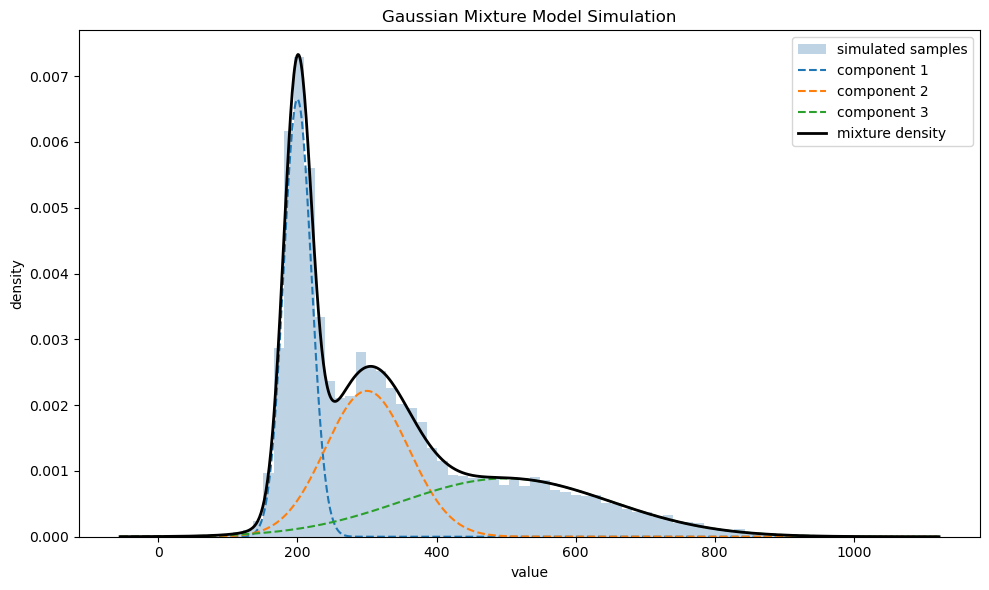

In [22]:
def normal_pdf(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))

x = np.linspace(samples.min(), samples.max(), 1_000)
component_densities = np.array([
    weight * normal_pdf(x, mean, std)
    for weight, mean, std in zip(weights, means, stds)
])
mixture_density = component_densities.sum(axis=0)

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=80, density=True, alpha=0.35, color="steelblue", label="simulated samples")

for i, density in enumerate(component_densities):
    plt.plot(x, density, linestyle="--", label=f"component {i + 1}")

plt.plot(x, mixture_density, color="black", linewidth=2, label="mixture density")
plt.xlabel("value")
plt.ylabel("density")
plt.title("Gaussian Mixture Model Simulation")
plt.legend()
plt.tight_layout()
plt.show()

## Fit a Gaussian Mixture Model

Fit a three-component GMM back to the simulated data and compare the fitted parameters with the data-generating parameters.

In [23]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
gmm.fit(samples.reshape(-1, 1))

fitted_weights = gmm.weights_
fitted_means = gmm.means_.ravel()
fitted_stds = np.sqrt(gmm.covariances_.ravel())

order = np.argsort(fitted_means)
fitted_weights = fitted_weights[order]
fitted_means = fitted_means[order]
fitted_stds = fitted_stds[order]

In [24]:
print("True parameters:")
for i, (weight, mean, std) in enumerate(zip(weights, means, stds), start=1):
    print(f"  component {i}: weight={weight:.3f}, mean={mean:.2f}, std={std:.2f}")

print("\nFitted parameters:")
for i, (weight, mean, std) in enumerate(zip(fitted_weights, fitted_means, fitted_stds), start=1):
    print(f"  component {i}: weight={weight:.3f}, mean={mean:.2f}, std={std:.2f}")

True parameters:
  component 1: weight=0.333, mean=200.00, std=20.00
  component 2: weight=0.333, mean=300.00, std=60.00
  component 3: weight=0.333, mean=500.00, std=150.00

Fitted parameters:
  component 1: weight=0.359, mean=201.66, std=21.29
  component 2: weight=0.376, mean=311.19, std=63.85
  component 3: weight=0.265, mean=539.97, std=138.60


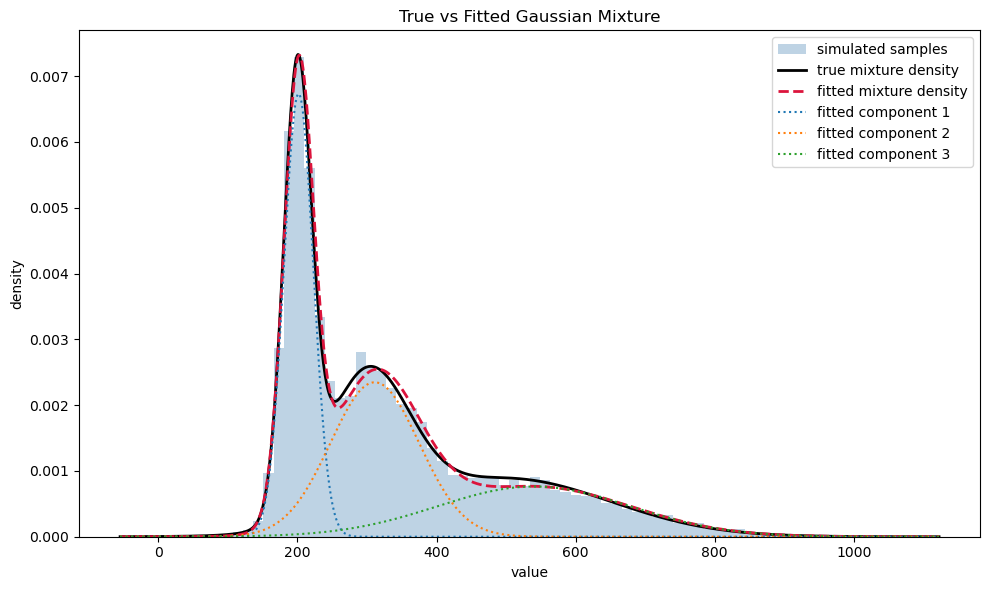

In [25]:
fitted_component_densities = np.array([
    weight * normal_pdf(x, mean, std)
    for weight, mean, std in zip(fitted_weights, fitted_means, fitted_stds)
])
fitted_mixture_density = fitted_component_densities.sum(axis=0)

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=80, density=True, alpha=0.35, color="steelblue", label="simulated samples")
plt.plot(x, mixture_density, color="black", linewidth=2, label="true mixture density")
plt.plot(x, fitted_mixture_density, color="crimson", linewidth=2, linestyle="--", label="fitted mixture density")

for i, density in enumerate(fitted_component_densities):
    plt.plot(x, density, linestyle=":", label=f"fitted component {i + 1}")

plt.xlabel("value")
plt.ylabel("density")
plt.title("True vs Fitted Gaussian Mixture")
plt.legend()
plt.tight_layout()
plt.show()

## Component Probabilities by Sample

Create a dataframe with each sample value and the fitted posterior probability that it belongs to each Gaussian component.

In [26]:
import pandas as pd

posterior_probabilities = gmm.predict_proba(samples.reshape(-1, 1))[:, order]
component_labels = np.array(["low_mean_component", "mid_mean_component", "high_mean_component"])
predicted_components = component_labels[np.argmax(posterior_probabilities, axis=1)]

sample_probabilities = pd.DataFrame({
    "sample_id": np.arange(1, n_samples + 1),
    "sample_value": samples,
    "predicted_component": predicted_components,
    "prob_low_mean_component": posterior_probabilities[:, 0],
    "prob_mid_mean_component": posterior_probabilities[:, 1],
    "prob_high_mean_component": posterior_probabilities[:, 2],
})

sample_probabilities.head()

,sample_id,sample_value,predicted_component,prob_low_mean_component,prob_mid_mean_component,prob_high_mean_component
0,1,217.500740,low_mean_component,8.571444e-01,1.343013e-01,0.008554
1,2,367.828671,mid_mean_component,2.033329e-13,8.177750e-01,0.182225
2,3,677.408729,high_mean_component,4.892072e-108,3.616602e-07,1.000000
3,4,428.844978,high_mean_component,1.259952e-24,4.371443e-01,0.562856
4,5,210.425519,low_mean_component,8.956374e-01,9.782129e-02,0.006541
